# Stage 3: XGBoost Triage Gate

SimGuard pipeline, Stage 3. XGBoost combines Isolation Forest's score (already inside the cohort Z-score feature set as `cohort_z_iso_anomaly_score`), the cohort Z-score features, and Prophet's burn-rate signal into one calibrated probability per SIM-day.

Gate: `< 0.10` auto-clear, `> 0.90` auto-flag, `0.10 to 0.90` escalates to Stage 4 (CBR).

The SHAP values computed here are saved as artifacts because Stage 4 CBR will use them as per-feature weights.

Runs in Google Colab or locally from `ml-service/`. Paths are relative (`data`, `artifacts`). No git operations.

## 1. Imports and installs

In [1]:
%pip install -q xgboost shap scikit-learn pandas numpy matplotlib mlflow joblib pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import mlflow, mlflow.xgboost
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

warnings.filterwarnings("ignore")
print("xgboost", xgb.__version__, "| shap", shap.__version__, "| mlflow", mlflow.__version__)

C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


xgboost 3.4.1 | shap 0.52.0 | mlflow 3.16.1


## 2. Seed, paths, MLflow experiment

In [3]:
SEED = 42
np.random.seed(SEED)

DATA_DIR = "data"
ARTIFACT_DIR = "artifacts"

# If the notebook is started from ml-service/notebooks, step up to ml-service/
if not os.path.isdir(DATA_DIR) and os.path.isdir(os.path.join("..", DATA_DIR)):
    os.chdir("..")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

GATE_LOW, GATE_HIGH = 0.10, 0.90

MLFLOW_DB = "sqlite:///mlruns.db"
mlflow.set_tracking_uri(MLFLOW_DB)
EXPERIMENT_NAME = "simguard-stage3-xgboost-triage"
mlflow.set_experiment(EXPERIMENT_NAME)

print("CWD          :", os.getcwd())
print("DATA_DIR     :", DATA_DIR, "| exists:", os.path.isdir(DATA_DIR))
print("ARTIFACT_DIR :", ARTIFACT_DIR)
print("Tracking URI :", mlflow.get_tracking_uri())
print("Experiment   :", EXPERIMENT_NAME)

CWD          : c:\Users\ADMIN\Desktop\projects\simguard\ml-service
DATA_DIR     : data | exists: True
ARTIFACT_DIR : artifacts
Tracking URI : sqlite:///mlruns.db
Experiment   : simguard-stage3-xgboost-triage


## 3. Load cohort Z-score feature set (X_v2) and labels (y), kept separate

In [4]:
X_train = pd.read_parquet(f"{DATA_DIR}/X_train_v2.parquet")
X_val   = pd.read_parquet(f"{DATA_DIR}/X_val_v2.parquet")
X_test  = pd.read_parquet(f"{DATA_DIR}/X_test_v2.parquet")
y_train = pd.read_parquet(f"{DATA_DIR}/y_train.parquet")
y_val   = pd.read_parquet(f"{DATA_DIR}/y_val.parquet")
y_test  = pd.read_parquet(f"{DATA_DIR}/y_test.parquet")

FORBIDDEN = ["is_anomalous", "misuse_category"]
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    assert len(X) == len(y), f"{name}: X/y length mismatch"
    assert (X["sim_id"].values == y["sim_id"].values).all() and (X["date"].values == y["date"].values).all(), \
        f"{name}: X and y rows are not aligned on (sim_id, date)"
    assert not any(c in X.columns for c in FORBIDDEN), f"{name}: label column found in X"
    print(f"{name:<5} X={X.shape}  y={y.shape}  anomaly rate={y['is_anomalous'].mean():.4f}  SIMs={X['sim_id'].nunique()}")

train X=(63000, 48)  y=(63000, 4)  anomaly rate=0.0205  SIMs=700
val   X=(13500, 48)  y=(13500, 4)  anomaly rate=0.0388  SIMs=150
test  X=(13500, 48)  y=(13500, 4)  anomaly rate=0.0267  SIMs=150


## 4. Load Prophet features (per billing cycle, label-free)

In [5]:
PROPHET_COLS = ["sim_id", "billing_cycle_num", "recommendation", "recommended_tier",
                "projected_overage_mb", "days_to_depletion"]
prophet = pd.read_parquet(f"{DATA_DIR}/prophet_features.parquet")[PROPHET_COLS].copy()
prophet["billing_cycle_num"] = prophet["billing_cycle_num"].astype(int)   # stored as string in the parquet

assert not any(c in prophet.columns for c in FORBIDDEN)
assert not prophet.duplicated(["sim_id", "billing_cycle_num"]).any(), "Prophet has duplicate (sim_id, cycle) keys"
print("Prophet shape:", prophet.shape, "(per cycle, not per day)")
print("Cycles:", sorted(prophet["billing_cycle_num"].unique()), "| SIMs:", prophet["sim_id"].nunique())
print("\nrecommendation counts:\n", prophet["recommendation"].value_counts(dropna=False).to_string())
print("\nNaN per column:\n", prophet.isna().sum().to_string())

Prophet shape: (3000, 6) (per cycle, not per day)
Cycles: [np.int64(0), np.int64(1), np.int64(2)] | SIMs: 1000

recommendation counts:
 recommendation
downgrade    2378
no_change     610
upgrade        12

NaN per column:
 sim_id                     0
billing_cycle_num          0
recommendation             0
recommended_tier           0
projected_overage_mb       0
days_to_depletion       2988


## 5. Add `billing_cycle_num` to the daily features (same rule as the Prophet notebook)

In [6]:
SIM_START = pd.Timestamp("2025-01-01")   # must match prophet_burn_rate.ipynb
EXPECTED_CYCLES = {0, 1, 2}
splits = {"train": X_train, "val": X_val, "test": X_test}

for name, X in splits.items():
    day_offset = (X["date"] - SIM_START).dt.days
    X["billing_cycle_num"] = (day_offset // 30).astype(int)
    seen = set(X["billing_cycle_num"].unique())
    print(f"{name:<5} dates {X['date'].min().date()} to {X['date'].max().date()} | "
          f"day_offset {day_offset.min()}..{day_offset.max()} | cycles {sorted(seen)}")
    if not seen.issubset(EXPECTED_CYCLES):
        print(f"  WARNING: {name} has cycles outside 0-2 {sorted(seen - EXPECTED_CYCLES)}. "
              f"SIM_START ({SIM_START.date()}) may not match the Prophet notebook.")

train dates 2025-01-01 to 2025-03-31 | day_offset 0..89 | cycles [np.int64(0), np.int64(1), np.int64(2)]
val   dates 2025-01-01 to 2025-03-31 | day_offset 0..89 | cycles [np.int64(0), np.int64(1), np.int64(2)]
test  dates 2025-01-01 to 2025-03-31 | day_offset 0..89 | cycles [np.int64(0), np.int64(1), np.int64(2)]


## 6. Merge Prophet forecasts onto the daily rows (left join, broadcast across each cycle)

In [7]:
REC_CATS = ["upgrade", "downgrade", "no_change", "insufficient_history"]
PROPHET_REC_COLS = [f"prophet_rec_{c}" for c in REC_CATS]
unknown = set(prophet["recommendation"].dropna().unique()) - set(REC_CATS)
assert not unknown, f"Unexpected recommendation values: {unknown}"

merged, n_before = {}, {}
for name, X in splits.items():
    n_before[name] = len(X)
    m = X.merge(prophet, on=["sim_id", "billing_cycle_num"], how="left",
                indicator=True, validate="many_to_one")
    for c in REC_CATS:
        oh = (m["recommendation"] == c).astype(float)
        oh[m["recommendation"].isna()] = np.nan          # NaN where no Prophet match; filled in the next step
        m[f"prophet_rec_{c}"] = oh
    merged[name] = m
    print(f"{name:<5} merged shape {m.shape}")

train merged shape (63000, 58)
val   merged shape (13500, 58)
test  merged shape (13500, 58)


## 7. Row counts, merge NaN rate, and fill (with `prophet_missing_flag`)

In [8]:
NO_DEPLETION_SENTINEL = 31.0   # a 30-day cycle: "does not deplete within the cycle"

for name in list(merged):
    m = merged[name]
    unmatched = m["_merge"] == "left_only"
    print(f"{name:<5} rows before={n_before[name]:,} after={len(m):,}  unchanged={len(m) == n_before[name]}")
    assert len(m) == n_before[name], f"{name}: merge changed the row count"
    print(f"      Prophet merge NaN rows: {int(unmatched.sum()):,} ({unmatched.mean() * 100:.2f}%)")

    # Rows that matched but where Prophet itself had no value
    matched_nan_dtd = int((~unmatched & m["days_to_depletion"].isna()).sum())
    matched_nan_ovg = int((~unmatched & m["projected_overage_mb"].isna()).sum())
    print(f"      matched rows with NaN days_to_depletion: {matched_nan_dtd:,} "
          f"(Prophet: no depletion in cycle -> filled {NO_DEPLETION_SENTINEL}), "
          f"NaN projected_overage_mb: {matched_nan_ovg:,}")

    m["prophet_missing_flag"] = unmatched.astype(int)
    m[PROPHET_REC_COLS] = m[PROPHET_REC_COLS].fillna(0).astype(int)
    dtd = m["days_to_depletion"].copy()
    dtd[~unmatched & dtd.isna()] = NO_DEPLETION_SENTINEL
    m["days_to_depletion"] = dtd.fillna(0.0)
    m["projected_overage_mb"] = m["projected_overage_mb"].fillna(0.0)
    merged[name] = m.drop(columns=["_merge", "recommendation", "recommended_tier"])

X_train, X_val, X_test = merged["train"], merged["val"], merged["test"]

train rows before=63,000 after=63,000  unchanged=True
      Prophet merge NaN rows: 0 (0.00%)
      matched rows with NaN days_to_depletion: 62,850 (Prophet: no depletion in cycle -> filled 31.0), NaN projected_overage_mb: 0
val   rows before=13,500 after=13,500  unchanged=True
      Prophet merge NaN rows: 0 (0.00%)
      matched rows with NaN days_to_depletion: 13,350 (Prophet: no depletion in cycle -> filled 31.0), NaN projected_overage_mb: 0
test  rows before=13,500 after=13,500  unchanged=True
      Prophet merge NaN rows: 0 (0.00%)
      matched rows with NaN days_to_depletion: 13,440 (Prophet: no depletion in cycle -> filled 31.0), NaN projected_overage_mb: 0


## 8. Scaling decision: nothing is scaled here, on purpose

XGBoost is tree-based. Splits depend only on the ordering of feature values, so monotonic rescaling (RobustScaler, StandardScaler, Min-Max) cannot change which splits are chosen. Unlike Isolation Forest's distance-flavoured scores or any linear model, it gains nothing from scaling.

- The new Prophet columns (`projected_overage_mb`, `days_to_depletion`) stay in raw units. Raw MB and days are also easier to read in SHAP plots.
- The X_v2 columns were already scaled in earlier feature engineering and are left exactly as they are. No scaler is fitted or applied in this notebook.

Every other model in this project involved a scaling decision, so this is a deliberate omission and not an oversight.

In [9]:
print(X_train[["projected_overage_mb", "days_to_depletion", "prophet_missing_flag"] + PROPHET_REC_COLS].describe().T.round(2).to_string())

                                    count      mean       std      min       25%       50%       75%     max
projected_overage_mb              63000.0 -33309.25  15931.94 -95999.7 -41655.14 -30887.74 -24029.05  7149.5
days_to_depletion                 63000.0     30.92      1.65     -5.0     31.00     31.00     31.00    31.0
prophet_missing_flag              63000.0      0.00      0.00      0.0      0.00      0.00      0.00     0.0
prophet_rec_upgrade               63000.0      0.00      0.05      0.0      0.00      0.00      0.00     1.0
prophet_rec_downgrade             63000.0      0.79      0.41      0.0      1.00      1.00      1.00     1.0
prophet_rec_no_change             63000.0      0.21      0.41      0.0      0.00      0.00      0.00     1.0
prophet_rec_insufficient_history  63000.0      0.00      0.00      0.0      0.00      0.00      0.00     0.0


## 9. Final feature list and leakage guard

In [10]:
EXCLUDE = {"sim_id", "date", "billing_cycle_num"}
feature_cols = [c for c in X_train.columns if c not in EXCLUDE]

for name, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
    leaked = [c for c in FORBIDDEN if c in X.columns]
    assert not leaked, f"{name}: label columns present: {leaked}"
    assert list(X[feature_cols].columns) == feature_cols
assert not any(c in feature_cols for c in FORBIDDEN)

print(f"Final feature count: {len(feature_cols)}")
for i, c in enumerate(feature_cols, 1):
    print(f"{i:>3}. {c}")

Final feature count: 53
  1. total_download_mb
  2. total_upload_mb
  3. data_session_count
  4. data_duration_s
  5. hotspot_sessions
  6. public_apn_sessions
  7. unique_towers
  8. geo_flag_count
  9. peak_mb
 10. offpeak_mb
 11. total_mb
 12. roaming_sessions
 13. billed_mb
 14. voice_minutes_used
 15. sms_count
 16. voice_minutes_remaining
 17. sms_remaining
 18. billing_gap_mb
 19. billing_ratio
 20. offpeak_ratio
 21. public_apn_ratio
 22. upload_ratio
 23. bytes_per_session
 24. mean_session_duration_s
 25. hotspot_session_ratio
 26. has_geo_anomaly
 27. vol_rolling_7d_mean
 28. vol_rolling_7d_std
 29. vol_zscore_7d
 30. hotspot_sum_7d
 31. geo_sum_7d
 32. vol_rolling_14d_mean
 33. vol_rolling_14d_std
 34. vol_zscore_14d
 35. hotspot_sum_14d
 36. geo_sum_14d
 37. trend_slope_14d
 38. tier_field
 39. tier_manager
 40. tier_professional
 41. tier_support
 42. voice_utilization_ratio
 43. cohort_z_iso_anomaly_score
 44. cohort_z_total_mb
 45. cohort_z_vol_zscore_7d
 46. cohort_z_v

## 10. Class imbalance: `scale_pos_weight`

In [11]:
ytr = y_train["is_anomalous"].values
n_pos, n_neg = int((ytr == 1).sum()), int((ytr == 0).sum())
scale_pos_weight = n_neg / n_pos
print(f"train positives={n_pos:,}  negatives={n_neg:,}")
print(f"anomaly rate         : {n_pos / len(ytr):.4%}")
print(f"scale_pos_weight     : {scale_pos_weight:.4f}")

train positives=1,292  negatives=61,708
anomaly rate         : 2.0508%
scale_pos_weight     : 47.7616


## 11. Fit XGBClassifier with early stopping on validation PR-AUC

In [12]:
if mlflow.active_run():
    mlflow.end_run()
run = mlflow.start_run(run_name="xgboost_triage")

PARAMS = dict(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr", early_stopping_rounds=20,
    tree_method="hist", random_state=SEED, n_jobs=-1,
)
model = xgb.XGBClassifier(**PARAMS)
model.fit(X_train[feature_cols], y_train["is_anomalous"].values,
          eval_set=[(X_val[feature_cols], y_val["is_anomalous"].values)], verbose=False)

best_iteration = int(model.best_iteration)
print(f"n_estimators requested : {PARAMS['n_estimators']}")
print(f"best_iteration (0-idx) : {best_iteration}  (trees used: {best_iteration + 1})")
print(f"best val aucpr         : {model.best_score:.4f}")

mlflow.log_params({
    "scale_pos_weight": round(scale_pos_weight, 4), "max_depth": PARAMS["max_depth"],
    "n_estimators": PARAMS["n_estimators"], "learning_rate": PARAMS["learning_rate"],
    "early_stopping_rounds": PARAMS["early_stopping_rounds"], "best_iteration": best_iteration,
    "subsample": PARAMS["subsample"], "colsample_bytree": PARAMS["colsample_bytree"],
    "seed": SEED, "n_features": len(feature_cols),
})

n_estimators requested : 500
best_iteration (0-idx) : 83  (trees used: 84)
best val aucpr         : 0.9289


## 12. Predicted probabilities and direction check

In [13]:
p_val  = model.predict_proba(X_val[feature_cols])[:, 1]
p_test = model.predict_proba(X_test[feature_cols])[:, 1]
yv, yt = y_val["is_anomalous"].values, y_test["is_anomalous"].values

# Direction check: higher probability should mean more anomalous (no sign flip needed)
rng = np.random.default_rng(SEED)
idx = rng.choice(len(p_val), size=min(5000, len(p_val)), replace=False)
corr = np.corrcoef(p_val[idx], yv[idx])[0, 1]
print(f"corr(prob, is_anomalous) on 5,000 val rows: {corr:.4f}")
print(f"mean prob | anomalous: {p_val[yv == 1].mean():.4f}   normal: {p_val[yv == 0].mean():.4f}")
assert corr > 0, "Probability is not positively correlated with anomalies"
print("Direction check passed: higher probability = more anomalous")

corr(prob, is_anomalous) on 5,000 val rows: 0.8911
mean prob | anomalous: 0.8941   normal: 0.0720
Direction check passed: higher probability = more anomalous


## 13. Stage 3 gate

In [14]:
def gate(p):
    return np.where(p < GATE_LOW, "auto_clear", np.where(p > GATE_HIGH, "auto_flag", "escalated"))

BUCKETS = ["auto_clear", "escalated", "auto_flag"]
g_val, g_test = gate(p_val), gate(p_test)
for name, g in [("val", g_val), ("test", g_test)]:
    print(f"\n{name.upper()} gate buckets (n={len(g):,})")
    for b in BUCKETS:
        n = int((g == b).sum())
        print(f"  {b:<11} {n:>8,}  {n / len(g):>7.2%}")


VAL gate buckets (n=13,500)
  auto_clear    11,630   86.15%
  escalated      1,410   10.44%
  auto_flag        460    3.41%

TEST gate buckets (n=13,500)
  auto_clear    11,914   88.25%
  escalated      1,272    9.42%
  auto_flag        314    2.33%


## 14. Escalated band: baseline precision before CBR

In [15]:
def band_report(name, g, y):
    esc = g == "escalated"
    n_esc, a_esc = int(esc.sum()), int(y[esc].sum())
    total_anom = int(y.sum())
    print(f"\n{name.upper()}")
    print(f"  escalated rows            : {n_esc:,}")
    print(f"  anomalous in escalated    : {a_esc:,}  -> baseline precision {a_esc / n_esc if n_esc else float('nan'):.4f}")
    for b in BUCKETS:
        mask = g == b
        k = int(y[mask].sum())
        print(f"  anomalies in {b:<10}   : {k:>6,}  ({k / total_anom:.2%} of all anomalies)")
    flag = g == "auto_flag"
    clr = g == "auto_clear"
    print(f"  auto_flag precision       : {y[flag].mean() if flag.any() else float('nan'):.4f}")
    print(f"  auto_clear anomaly rate   : {y[clr].mean() if clr.any() else float('nan'):.4f}  (missed anomalies sit here)")
    return a_esc / n_esc if n_esc else float("nan")

esc_prec_val = band_report("val", g_val, yv)
esc_prec_test = band_report("test", g_test, yt)


VAL
  escalated rows            : 1,410
  anomalous in escalated    : 34  -> baseline precision 0.0241
  anomalies in auto_clear   :     35  (6.68% of all anomalies)
  anomalies in escalated    :     34  (6.49% of all anomalies)
  anomalies in auto_flag    :    455  (86.83% of all anomalies)
  auto_flag precision       : 0.9891
  auto_clear anomaly rate   : 0.0030  (missed anomalies sit here)

TEST
  escalated rows            : 1,272
  anomalous in escalated    : 35  -> baseline precision 0.0275
  anomalies in auto_clear   :     17  (4.71% of all anomalies)
  anomalies in escalated    :     35  (9.70% of all anomalies)
  anomalies in auto_flag    :    309  (85.60% of all anomalies)
  auto_flag precision       : 0.9841
  auto_clear anomaly rate   : 0.0014  (missed anomalies sit here)


## 15. Overall precision / recall / F1 at 0.5 and at the auto-flag threshold (0.90)

In [16]:
def overall(y, p, thr):
    pred = (p >= thr).astype(int)
    return dict(precision=precision_score(y, pred, zero_division=0),
                recall=recall_score(y, pred, zero_division=0),
                f1=f1_score(y, pred, zero_division=0))

rows = []
for name, y, p in [("val", yv, p_val), ("test", yt, p_test)]:
    for thr in (0.5, GATE_HIGH):
        r = overall(y, p, thr); r.update(split=name, threshold=thr); rows.append(r)
    rows.append(dict(split=name, threshold="PR-AUC", precision=average_precision_score(y, p), recall=np.nan, f1=np.nan))
overall_df = pd.DataFrame(rows)[["split", "threshold", "precision", "recall", "f1"]]
print(overall_df.round(4).to_string(index=False))

split threshold  precision  recall     f1
  val       0.5     0.9060  0.9008 0.9033
  val       0.9     0.9891  0.8683 0.9248
  val    PR-AUC     0.9289     NaN    NaN
 test       0.5     0.9081  0.9030 0.9056
 test       0.9     0.9841  0.8560 0.9156
 test    PR-AUC     0.9357     NaN    NaN


## 16. Per-category recall and full-set precision (labels joined here, only for evaluation)

In [17]:
MISUSE_CATS = ["ghost_usage", "unauthorized_sharing", "data_reselling", "inactive_billing", "normal"]

# Evaluation frames: the only place misuse_category is joined to the rows
eval_val  = X_val[["sim_id", "date"]].assign(is_anomalous=yv, misuse_category=y_val["misuse_category"].values, prob=p_val)
eval_test = X_test[["sim_id", "date"]].assign(is_anomalous=yt, misuse_category=y_test["misuse_category"].values, prob=p_test)

def category_table(ev, thr):
    """Recall within each category; precision over the FULL set: TP / (TP + FP), FP = flagged rows not in that category."""
    flagged = (ev["prob"] >= thr).values
    out = []
    for cat in MISUSE_CATS:
        in_cat = (ev["misuse_category"] == cat).values
        if cat == "normal":                       # 'correct' for normal = predicted not flagged
            hit = ~flagged
        else:
            hit = flagged
        tp = int((hit & in_cat).sum()); fp = int((hit & ~in_cat).sum())
        rec = tp / in_cat.sum() if in_cat.sum() else np.nan
        pre = tp / (tp + fp) if (tp + fp) else 0.0
        f1 = 2 * pre * rec / (pre + rec) if (pre + rec) else 0.0
        out.append(dict(category=cat, n=int(in_cat.sum()), precision=pre, recall=rec, f1=f1))
    return pd.DataFrame(out)

cat_tables = {}
for sname, ev in [("val", eval_val), ("test", eval_test)]:
    for thr in (0.5, GATE_HIGH):
        t = category_table(ev, thr)
        cat_tables[(sname, thr)] = t
        print(f"\n{sname.upper()} per-category at threshold {thr}")
        print(t.round(4).to_string(index=False))


VAL per-category at threshold 0.5
            category     n  precision  recall     f1
         ghost_usage   150     0.2687  0.9333 0.4173
unauthorized_sharing   217     0.3608  0.8664 0.5095
      data_reselling   101     0.1785  0.9208 0.2990
    inactive_billing    56     0.0979  0.9107 0.1768
              normal 12976     0.9960  0.9962 0.9961

VAL per-category at threshold 0.9
            category     n  precision  recall     f1
         ghost_usage   150     0.3043  0.9333 0.4590
unauthorized_sharing   217     0.3891  0.8249 0.5288
      data_reselling   101     0.1848  0.8416 0.3030
    inactive_billing    56     0.1109  0.9107 0.1977
              normal 12976     0.9947  0.9996 0.9972

TEST per-category at threshold 0.5
            category     n  precision  recall     f1
         ghost_usage    80     0.2006  0.9000 0.3280
unauthorized_sharing   235     0.5989  0.9149 0.7239
      data_reselling    24     0.0557  0.8333 0.1044
    inactive_billing    22     0.0529  0.8636 

## 17. Comparison against Isolation Forest and the cohort Z-score results

In [18]:
IF_RECALL  = {"ghost_usage": 0.1667, "unauthorized_sharing": 0.8295, "data_reselling": 0.3663, "inactive_billing": 0.8571}
Z_DELTA    = {"ghost_usage": 0.02, "data_reselling": 0.13, "unauthorized_sharing": 0.06, "inactive_billing": 0.08}

def compare(sname):
    t05 = cat_tables[(sname, 0.5)].set_index("category")
    t90 = cat_tables[(sname, GATE_HIGH)].set_index("category")
    rows = []
    for cat in IF_RECALL:
        rows.append(dict(
            category=cat,
            IF_recall=IF_RECALL[cat],
            IF_plus_Z_approx=IF_RECALL[cat] + Z_DELTA[cat],
            XGB_recall_at_0_5=t05.loc[cat, "recall"],
            XGB_recall_at_0_9=t90.loc[cat, "recall"],
            XGB_precision_at_0_5=t05.loc[cat, "precision"],
        ))
    df = pd.DataFrame(rows)
    df["delta_vs_IF"] = df["XGB_recall_at_0_5"] - df["IF_recall"]
    df["delta_vs_IF_plus_Z"] = df["XGB_recall_at_0_5"] - df["IF_plus_Z_approx"]
    return df

for sname in ("val", "test"):
    cmp_df = compare(sname)
    print(f"\n{sname.upper()}: recall comparison (XGBoost at the standard 0.5 threshold)")
    print(cmp_df.round(4).to_string(index=False))
    print("Verdicts:")
    for _, r in cmp_df.iterrows():
        v_if = "BEATS" if r["delta_vs_IF"] > 0 else "does NOT beat"
        v_z = "BEATS" if r["delta_vs_IF_plus_Z"] > 0 else "does NOT beat"
        print(f"  {r['category']:<22} XGBoost {v_if} Isolation Forest ({r['delta_vs_IF']:+.4f}); "
              f"{v_z} the IF + cohort Z estimate ({r['delta_vs_IF_plus_Z']:+.4f})")

print("\nNotes: IF recalls and Z-score deltas are the numbers already on record. The Z-score deltas are assumed to be recall "
      "gains over the IF baseline, so IF_plus_Z_approx is an estimate, not a re-run. The IF numbers may come from a "
      "different split or threshold than the ones here.")


VAL: recall comparison (XGBoost at the standard 0.5 threshold)
            category  IF_recall  IF_plus_Z_approx  XGB_recall_at_0_5  XGB_recall_at_0_9  XGB_precision_at_0_5  delta_vs_IF  delta_vs_IF_plus_Z
         ghost_usage     0.1667            0.1867             0.9333             0.9333                0.2687       0.7666              0.7466
unauthorized_sharing     0.8295            0.8895             0.8664             0.8249                0.3608       0.0369             -0.0231
      data_reselling     0.3663            0.4963             0.9208             0.8416                0.1785       0.5545              0.4245
    inactive_billing     0.8571            0.9371             0.9107             0.9107                0.0979       0.0536             -0.0264
Verdicts:
  ghost_usage            XGBoost BEATS Isolation Forest (+0.7666); BEATS the IF + cohort Z estimate (+0.7466)
  unauthorized_sharing   XGBoost BEATS Isolation Forest (+0.0369); does NOT beat the IF + cohort Z es

## 18. SHAP values on validation (TreeExplainer) and summary plot

shap.TreeExplainer additivity max abs error: 9.38e-01
native additivity max abs error: 3.34e-06
SHAP source: xgboost pred_contribs


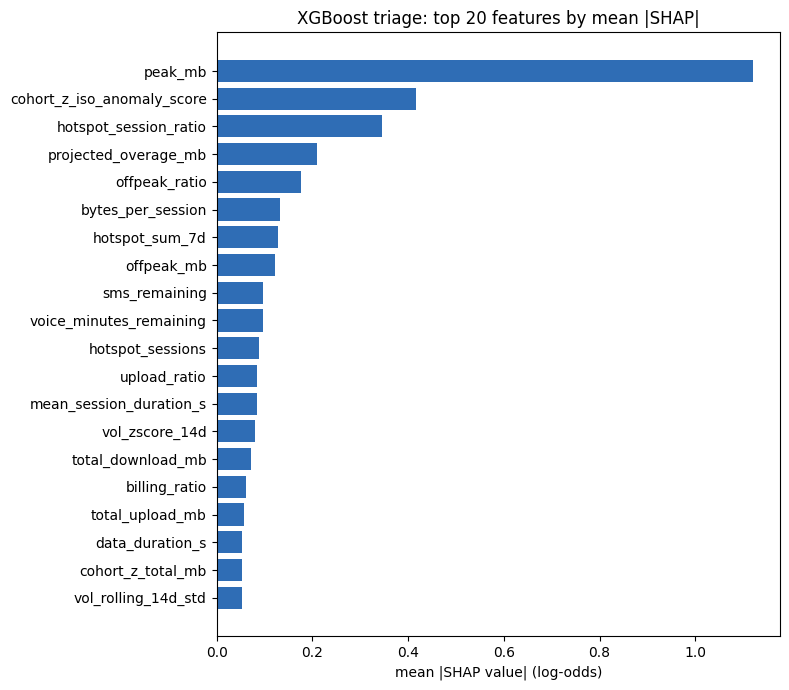

In [19]:
dval = xgb.DMatrix(X_val[feature_cols])
margin = model.get_booster().predict(dval, output_margin=True)      # raw log-odds

explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_val[feature_cols])
if isinstance(sv, list):          # older shap versions return one array per class
    sv = sv[1]
sv = np.asarray(sv)
base_value = float(np.ravel(explainer.expected_value)[-1])
assert sv.shape == (len(X_val), len(feature_cols)), sv.shape

# Additivity check: base + sum(SHAP) must equal the model's raw margin (log-odds)
err = np.abs(base_value + sv.sum(axis=1) - margin).max()
print(f"shap.TreeExplainer additivity max abs error: {err:.2e}")
SHAP_SOURCE = "shap.TreeExplainer"
if err > 1e-3:
    # shap/xgboost version mismatch: use XGBoost's built-in TreeSHAP (same algorithm, exact and additive)
    print("WARNING: shap.TreeExplainer is not additive for this shap/xgboost combination. "
          "Falling back to XGBoost native pred_contribs (exact TreeSHAP).")
    contrib = model.get_booster().predict(dval, pred_contribs=True)
    sv, base_value = contrib[:, :-1], float(contrib[0, -1])
    err = np.abs(base_value + sv.sum(axis=1) - margin).max()
    SHAP_SOURCE = "xgboost pred_contribs"
    print(f"native additivity max abs error: {err:.2e}")
SHAP_ADDITIVE = bool(err < 1e-3)
print("SHAP source:", SHAP_SOURCE)

mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=feature_cols).sort_values(ascending=False)
top20 = mean_abs.head(20)[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20.index, top20.values, color="#2f6db5")
ax.set_xlabel("mean |SHAP value| (log-odds)")
ax.set_title("XGBoost triage: top 20 features by mean |SHAP|")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/shap_summary.png", dpi=150)
plt.show()

## 19. Save SHAP values for the escalated band (Stage 4 CBR input)

In [20]:
esc_mask = (p_val >= GATE_LOW) & (p_val <= GATE_HIGH)
shap_esc = sv[esc_mask]
esc_index = X_val.loc[esc_mask, ["sim_id", "date", "billing_cycle_num"]].reset_index(drop=True)
assert len(shap_esc) == len(esc_index)

np.save(f"{ARTIFACT_DIR}/shap_values_escalated.npy", shap_esc)
esc_index.to_csv(f"{ARTIFACT_DIR}/shap_values_escalated_index.csv", index=False)
with open(f"{ARTIFACT_DIR}/shap_base_value.json", "w") as f:
    json.dump({"base_value_log_odds": base_value, "shap_source": SHAP_SOURCE, "feature_cols": feature_cols}, f, indent=2)

print("shap_values_escalated.npy        :", shap_esc.shape, "(rows = escalated val rows, cols = feature_cols order)")
print("shap_values_escalated_index.csv  :", esc_index.shape)
print("Row i of the .npy matches row i of the CSV. SHAP units are log-odds.")

shap_values_escalated.npy        : (1410, 53) (rows = escalated val rows, cols = feature_cols order)
shap_values_escalated_index.csv  : (1410, 3)
Row i of the .npy matches row i of the CSV. SHAP units are log-odds.


## 20. Top 10 SHAP features vs Isolation Forest permutation importance

In [21]:
IF_TOP = ["hotspot_session_ratio", "hotspot_sessions", "hotspot_sum_7d", "hotspot_sum_14d", "billing_ratio", "billing_gap_mb"]
top10 = mean_abs.head(10)
print("Top 10 features by mean |SHAP|:")
for i, (f, v) in enumerate(top10.items(), 1):
    tag = "prophet" if f.startswith("prophet_") or f in ("projected_overage_mb", "days_to_depletion") \
        else "cohort_z" if f.startswith("cohort_z_") else "base"
    print(f"{i:>3}. {f:<32} {v:.4f}  [{tag}]{'  <- also in IF top features' if f in IF_TOP else ''}")

is_prophet = lambda f: f.startswith("prophet_") or f in ("projected_overage_mb", "days_to_depletion")
is_cohort  = lambda f: f.startswith("cohort_z_")
total = mean_abs.sum()
share = {
    "prophet":  mean_abs[[f for f in feature_cols if is_prophet(f)]].sum() / total,
    "cohort_z": mean_abs[[f for f in feature_cols if is_cohort(f)]].sum() / total,
    "IF_top_features": mean_abs[[f for f in IF_TOP if f in feature_cols]].sum() / total,
}
print("\nShare of total mean |SHAP|:")
for k, v in share.items():
    print(f"  {k:<16} {v:.1%}")

ranks = {f: int(i + 1) for i, f in enumerate(mean_abs.index)}
best_p = min((f for f in feature_cols if is_prophet(f)), key=ranks.get)
best_z = min((f for f in feature_cols if is_cohort(f)), key=ranks.get)
print(f"\nBest-ranked Prophet feature : {best_p} (rank {ranks[best_p]} of {len(feature_cols)})")
print(f"Best-ranked cohort-Z feature: {best_z} (rank {ranks[best_z]} of {len(feature_cols)})")
print(f"IF top features in SHAP top 10: {[f for f in top10.index if f in IF_TOP]}")

for label, key in [("Prophet-derived", "prophet"), ("Cohort Z-score", "cohort_z")]:
    verdict = "MEANINGFUL" if share[key] >= 0.10 else "NOT meaningful"
    print(f"{label} features: {verdict} (rule: >= 10% of total mean |SHAP|; actual {share[key]:.1%})")
if share["IF_top_features"] >= 0.5:
    print("XGBoost leans mostly on the same signals Isolation Forest already found.")
else:
    print(f"IF's top signals carry {share['IF_top_features']:.1%} of attribution, XGBoost is not relying on them alone.")

Top 10 features by mean |SHAP|:
  1. peak_mb                          1.1208  [base]
  2. cohort_z_iso_anomaly_score       0.4162  [cohort_z]
  3. hotspot_session_ratio            0.3453  [base]  <- also in IF top features
  4. projected_overage_mb             0.2091  [prophet]
  5. offpeak_ratio                    0.1773  [base]
  6. bytes_per_session                0.1314  [base]
  7. hotspot_sum_7d                   0.1278  [base]  <- also in IF top features
  8. offpeak_mb                       0.1219  [base]
  9. sms_remaining                    0.0978  [base]
 10. voice_minutes_remaining          0.0964  [base]

Share of total mean |SHAP|:
  prophet          5.3%
  cohort_z         13.0%
  IF_top_features  16.3%

Best-ranked Prophet feature : projected_overage_mb (rank 4 of 53)
Best-ranked cohort-Z feature: cohort_z_iso_anomaly_score (rank 2 of 53)
IF top features in SHAP top 10: ['hotspot_session_ratio', 'hotspot_sum_7d']
Prophet-derived features: NOT meaningful (rule: >= 10% of

## 21. Save model, feature list, and log to MLflow

In [22]:
joblib.dump(model, f"{ARTIFACT_DIR}/xgboost_triage.joblib")
with open(f"{ARTIFACT_DIR}/xgboost_feature_columns.json", "w") as f:
    json.dump(feature_cols, f, indent=2)

try:
    mlflow.xgboost.log_model(model, name="xgboost_triage")
except TypeError:                       # older MLflow
    mlflow.xgboost.log_model(model, artifact_path="xgboost_triage")

mlflow.log_metrics({
    "val_pr_auc": average_precision_score(yv, p_val), "test_pr_auc": average_precision_score(yt, p_test),
    "val_escalated_precision": esc_prec_val, "test_escalated_precision": esc_prec_test,
    "val_frac_escalated": float((g_val == "escalated").mean()), "test_frac_escalated": float((g_test == "escalated").mean()),
})
for fn in ["shap_summary.png", "shap_values_escalated.npy", "shap_values_escalated_index.csv",
           "shap_base_value.json", "xgboost_feature_columns.json"]:
    mlflow.log_artifact(f"{ARTIFACT_DIR}/{fn}")
mlflow.end_run()
print("Saved:", [f for f in sorted(os.listdir(ARTIFACT_DIR)) if f.startswith(("xgboost", "shap"))])

Saved: ['shap_base_value.json', 'shap_summary.png', 'shap_values_escalated.npy', 'shap_values_escalated_index.csv', 'xgboost_feature_columns.json', 'xgboost_triage.joblib']


## Sanity checks

In [23]:
checks = {}

# 1. No label columns anywhere in the merged splits
checks["X_train/val/test exclude is_anomalous and misuse_category"] = all(
    not any(c in X.columns for c in FORBIDDEN) for X in (X_train, X_val, X_test))

# 2. No NaN / inf in any final feature column
finite = all(np.isfinite(X[feature_cols].to_numpy(dtype=float)).all() for X in (X_train, X_val, X_test))
checks["no NaN or inf in final feature columns"] = finite

# 3. SIM-level split integrity
s_tr, s_va, s_te = (set(X["sim_id"]) for X in (X_train, X_val, X_test))
checks["no SIM appears in more than one split"] = not (s_tr & s_va or s_tr & s_te or s_va & s_te)

# 4. Row counts unchanged by the Prophet merge
checks["row counts unchanged by Prophet merge"] = all(len(X) == n_before[k] for k, X in zip(("train", "val", "test"), (X_train, X_val, X_test)))

checks["SHAP values additive (base + sum = model margin)"] = SHAP_ADDITIVE

# 5. Early stopping behaviour
n_req = PARAMS["n_estimators"]
print(f"Early stopping: best_iteration={best_iteration} (trees used {best_iteration + 1}) vs n_estimators requested={n_req}")
early_flag = best_iteration + 1 < 30
never_flag = best_iteration + 1 >= n_req - PARAMS["early_stopping_rounds"]
if early_flag:
    print("  FLAG: early stopping triggered very early (< 30 trees). Possible overfitting risk or weak signal.")
if never_flag:
    print("  FLAG: early stopping effectively never triggered. n_estimators may be too low.")
checks["early stopping in a healthy range (not very early, not exhausted)"] = not (early_flag or never_flag)

print()
for k, v in checks.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")
print("\nALL SANITY CHECKS PASSED" if all(checks.values()) else "\nSOME SANITY CHECKS FAILED, see above")

Early stopping: best_iteration=83 (trees used 84) vs n_estimators requested=500

[PASS] X_train/val/test exclude is_anomalous and misuse_category
[PASS] no NaN or inf in final feature columns
[PASS] no SIM appears in more than one split
[PASS] row counts unchanged by Prophet merge
[PASS] SHAP values additive (base + sum = model margin)
[PASS] early stopping in a healthy range (not very early, not exhausted)

ALL SANITY CHECKS PASSED
